In [25]:
from bs4 import BeautifulSoup
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torchtext.vocab import build_vocab_from_iterator
import nltk
from nltk.tokenize import word_tokenize
import os
import tqdm

In [12]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/alfred/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
regex = re.compile(r"\((\d+), '([^']+)', '([^']+)', (\d+), ('[^']+'\))")

mapper = dict()

with open('n96ncsr5g4-1/index.txt', 'r') as file:
    fields = file.readlines()
    for field in fields:
        match = re.match(regex, field)
        if match:
            mapper[match.group(3)] = match.group(4)

print(len(mapper))


79987


In [3]:
files = []

for part in range(1, 7):  # Dataset parts 1 to 6
    dataset_path = f'n96ncsr5g4-1/dataset/dataset-part-{part}'
    for file in os.listdir(dataset_path):
        full_path = f'{dataset_path}/{file}'
        files.append(full_path)

X = []
y = []
max_files = 50

for file in files[:50]:
    # Extract the filename from the full path
    filename = file.split('/')[-1]
    if filename in mapper:
        with open(file, 'r') as file:
            html_content = file.read()
            soup = BeautifulSoup(html_content, 'html.parser')
            text = soup.get_text()
            text = text.strip()
            X.append(text)
            y.append(mapper[filename])

### Exploratory Data Analysis

       File Index    Word Count  Character Count  Unique Word Count  \
count    49.00000     49.000000        49.000000          49.000000   
mean     24.00000   1177.387755     12241.142857         374.306122   
std      14.28869   2604.566517     26567.971300         656.244689   
min       0.00000      0.000000         0.000000           0.000000   
25%      12.00000     33.000000       531.000000          30.000000   
50%      24.00000    162.000000      1757.000000         118.000000   
75%      36.00000    959.000000     13595.000000         523.000000   
max      48.00000  15388.000000    159045.000000        3772.000000   

       Unique Character Count  
count               49.000000  
mean                64.857143  
std                 43.929868  
min                  0.000000  
25%                 41.000000  
50%                 60.000000  
75%                 80.000000  
max                246.000000  


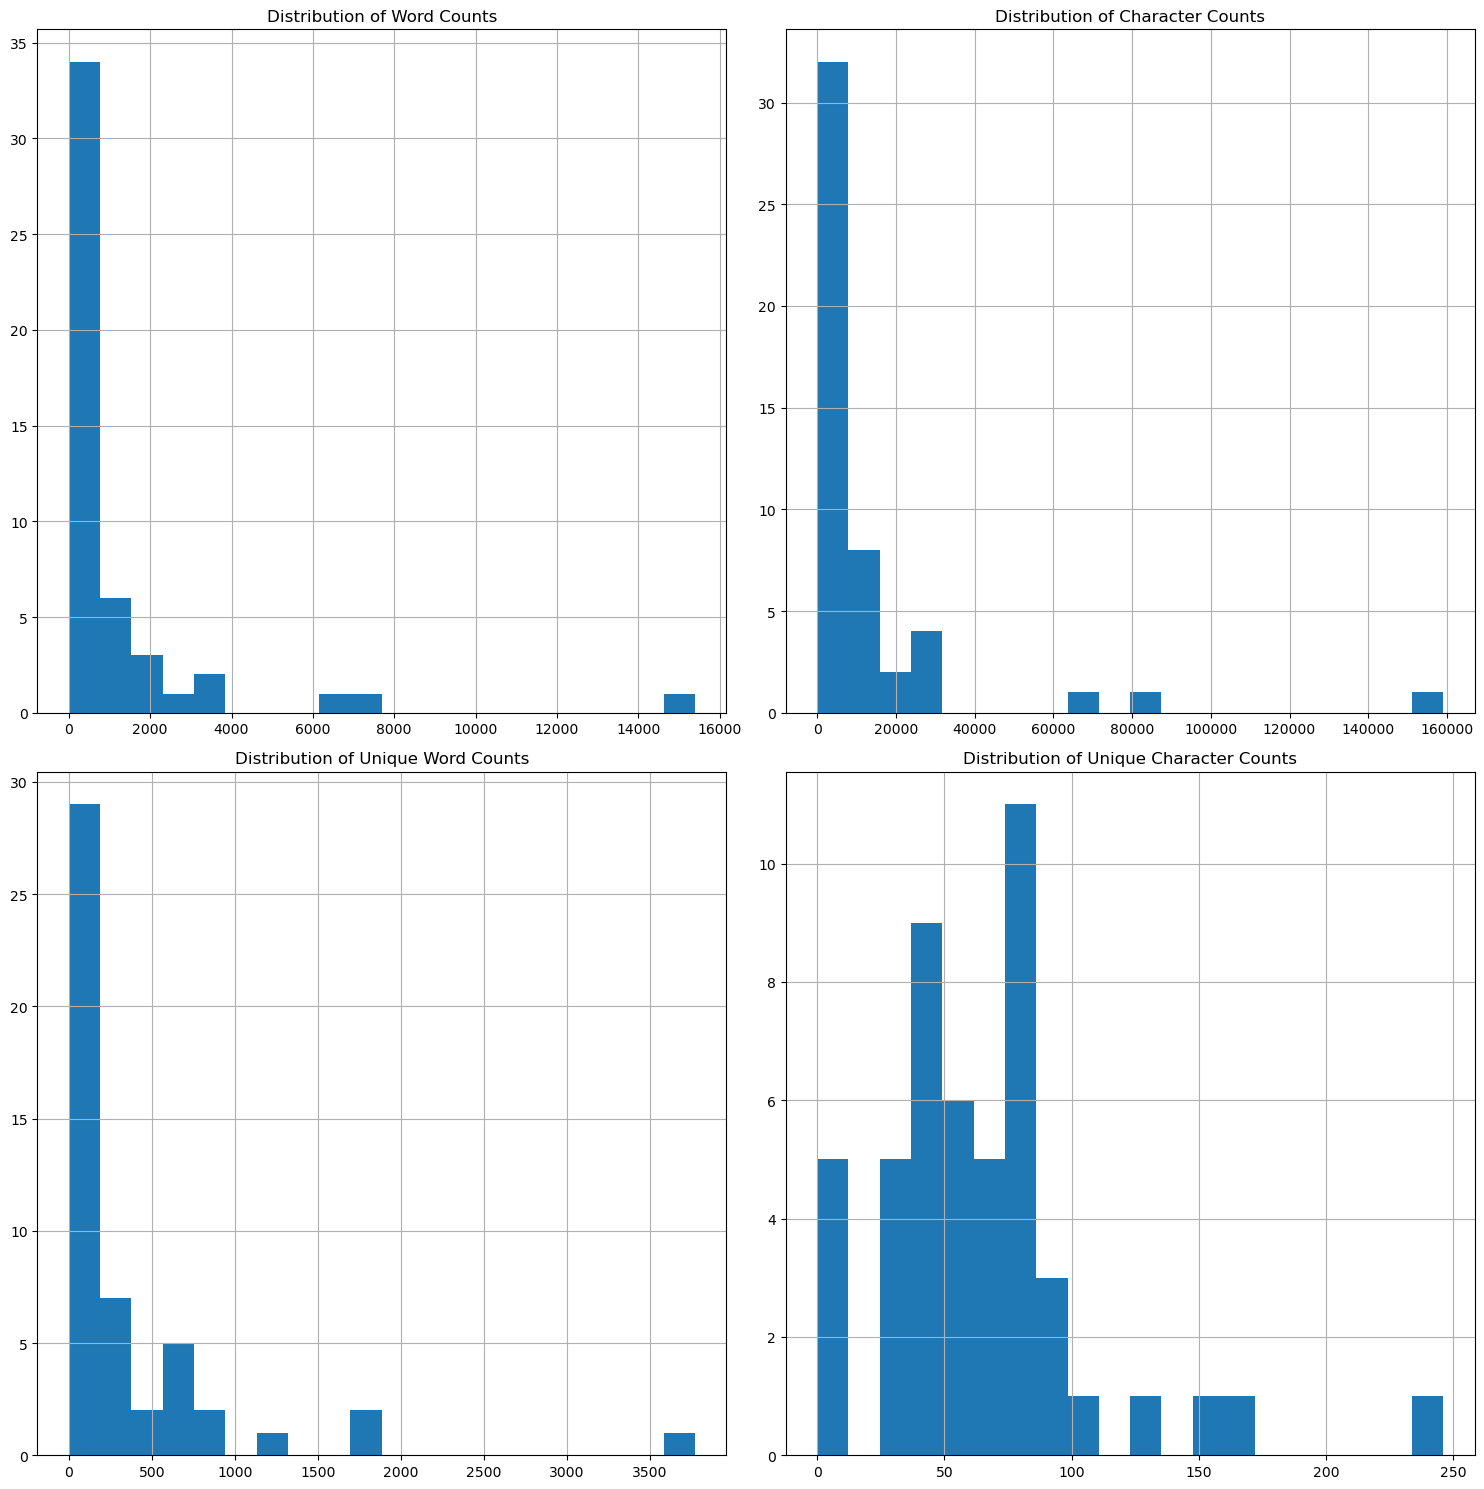


Top 10 most common words:
[('the', 1677), ('-', 1227), ('of', 1196), ('and', 1102), ('to', 857), ('in', 718), ('a', 668), ('.', 539), ('The', 515), (',', 469)]

Top 10 most common characters:
[(' ', 287167), ('\n', 54941), ('e', 25347), ('o', 18058), ('a', 17558), ('t', 17240), ('n', 16193), ('i', 16075), ('r', 15528), ('s', 13677)]

Average word length: 5.08 characters


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Create a list to store the analysis results
analysis_results = []

for i, (text, label) in enumerate(zip(X, y)):
    # Count words and characters
    words = word_tokenize(text)
    chars = list(text)
    
    # Count unique words and characters
    unique_words = set(words)
    unique_chars = set(chars)
    
    # Store the results
    analysis_results.append({
        'File Index': i,
        'Label': label,
        'Word Count': len(words),
        'Character Count': len(chars),
        'Unique Word Count': len(unique_words),
        'Unique Character Count': len(unique_chars)
    })

# Convert to DataFrame for easy analysis
df = pd.DataFrame(analysis_results)

# Display summary statistics
print(df.describe())

# Plot histograms
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
df['Word Count'].hist(ax=axs[0, 0], bins=20)
axs[0, 0].set_title('Distribution of Word Counts')
df['Character Count'].hist(ax=axs[0, 1], bins=20)
axs[0, 1].set_title('Distribution of Character Counts')
df['Unique Word Count'].hist(ax=axs[1, 0], bins=20)
axs[1, 0].set_title('Distribution of Unique Word Counts')
df['Unique Character Count'].hist(ax=axs[1, 1], bins=20)
axs[1, 1].set_title('Distribution of Unique Character Counts')
plt.tight_layout()
plt.show()

# Display top 10 most common words and characters across all files
all_words = [word for text in X for word in text.split()]
all_chars = [char for text in X for char in list(text)]

print("\nTop 10 most common words:")
print(Counter(all_words).most_common(10))

print("\nTop 10 most common characters:")
print(Counter(all_chars).most_common(10))

# Calculate and display average word length
avg_word_length = sum(len(word) for word in all_words) / len(all_words)
print(f"\nAverage word length: {avg_word_length:.2f} characters")


In [10]:
# Analyze non-alphanumeric characters in files
non_alphanumeric_analysis = []

for i, text in enumerate(X):
    non_alphanumeric = set(char for char in text if not char.isalnum() and not char.isspace())
    if non_alphanumeric:
        non_alphanumeric_analysis.append({
            'File Index': i,
            'Non-alphanumeric Characters': list(non_alphanumeric)
        })

# List all unique non-alphanumeric characters
all_non_alphanumeric = set(char for item in non_alphanumeric_analysis for char in item['Non-alphanumeric Characters'])
print("All non-alphanumeric characters found:")
print(', '.join(sorted(all_non_alphanumeric)))


All non-alphanumeric characters found:
!, ", #, $, %, &, ', (, ), *, +, ,, -, ., /, :, ;, <, =, >, ?, @, [, \, ], ^, _, `, {, |, }, ¡, £, ©, ­, ®, °, ¶, ·, », ×, ि, ी, ्, ி, ், ം, ാ, –, —, ‘, ’, “, ”, •, …, ′, ″, ›, ℠, ™, ←, ↑, →, ⇗, ▼, ✖, ❐, ⬈, 、, ・, , ﻿, ！, （, ）, ．, ：, ＜, ＞, 📓, 😉



Total number of unique words across all files: 11258
Average length of unique words: 6.78 characters
Longest word length: 111 characters
Shortest word length: 1 characters


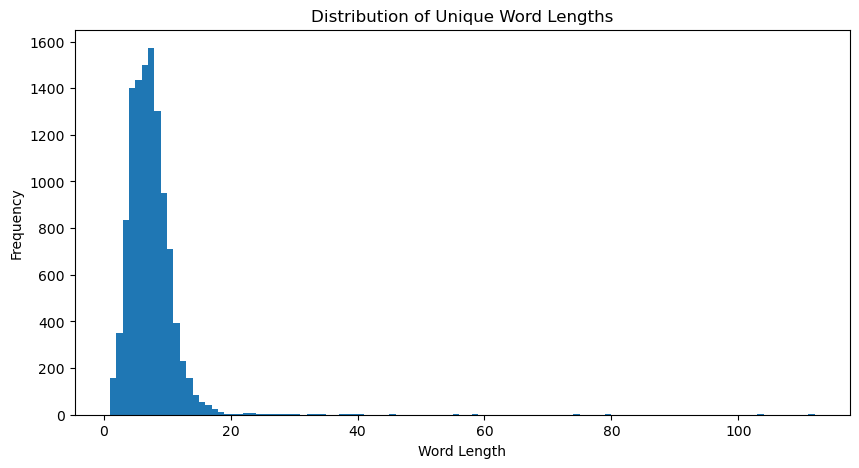


Examples of longest words (length 111):
//hummedia.manchester.ac.uk/institutes/code/briefingsupdated/has-neighbourhood-ethnic-segregation-decreased.pdf

Examples of shortest words (length 1):
o, V, C, #, , &, ›, P, p, Z


In [15]:
# Analyze unique words across all files
all_unique_words = set(word for text in X for word in word_tokenize(text))

print(f"\nTotal number of unique words across all files: {len(all_unique_words)}")

# Display some statistics about word lengths
word_lengths = [len(word) for word in all_unique_words]
avg_word_length = sum(word_lengths) / len(word_lengths)
max_word_length = max(word_lengths)
min_word_length = min(word_lengths)

print(f"Average length of unique words: {avg_word_length:.2f} characters")
print(f"Longest word length: {max_word_length} characters")
print(f"Shortest word length: {min_word_length} characters")

# Display distribution of word lengths
plt.figure(figsize=(10, 5))
plt.hist(word_lengths, bins=range(min_word_length, max_word_length + 2, 1))
plt.title('Distribution of Unique Word Lengths')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

# Display some examples of long and short words
long_words = [word for word in all_unique_words if len(word) == max_word_length]
short_words = [word for word in all_unique_words if len(word) == min_word_length]

print(f"\nExamples of longest words (length {max_word_length}):")
print(', '.join(long_words[:10]))  # Display up to 10 examples

print(f"\nExamples of shortest words (length {min_word_length}):")
print(', '.join(short_words[:10]))  # Display up to 10 examples


In [18]:
# Analyze non-ASCII words and their frequencies
from collections import Counter
import unicodedata

def is_ascii(s):
    return all(ord(c) < 128 for c in s)

non_ascii_words = [word for text in X for word in word_tokenize(text) if not is_ascii(word)]
non_ascii_word_freq = Counter(non_ascii_words)

print(f"Total number of unique non-ASCII words: {len(non_ascii_word_freq)}")

# Sort non-ASCII words by frequency (descending order)
sorted_non_ascii_words = sorted(non_ascii_word_freq.items(), key=lambda x: x[1], reverse=True)

print("\nTop 20 most frequent non-ASCII words and their frequencies:")
for word, freq in sorted_non_ascii_words[:20]:
    print(f"{word}: {freq}")

# Function to get Unicode category for a character
def get_unicode_category(char):
    return unicodedata.category(char)

# Analyze Unicode categories of non-ASCII characters
non_ascii_char_categories = Counter()
for word in non_ascii_words:
    for char in word:
        if not is_ascii(char):
            non_ascii_char_categories[get_unicode_category(char)] += 1

print("\nUnicode categories of non-ASCII characters:")
for category, count in non_ascii_char_categories.most_common():
    print(f"{category}: {count}")


Total number of unique non-ASCII words: 544

Top 20 most frequent non-ASCII words and their frequencies:
’: 101
–: 93
©: 31
—: 23
¶: 23
•: 23
“: 22
”: 22
›: 19
…: 13
↑: 10
﻿: 8
×: 8
и: 7
·: 7
я: 6
в: 6
Français: 6
HuracÃ¡n: 6
SarandÃ­: 6

Unicode categories of non-ASCII characters:
Ll: 1641
Lo: 279
Pd: 201
Lu: 152
Pf: 147
Po: 123
So: 108
Sm: 26
Pi: 25
Sc: 19
Cf: 16
Lm: 12
No: 8
Mc: 5
Mn: 2
Co: 2
Nd: 1
Ps: 1
Pe: 1


### Preprocessing

In [19]:
# Tokenization (character-level and word-level)
def tokenize_char(doc):
    return list(doc)  # Character-level tokenization

def tokenize_word(doc):
    return word_tokenize(doc)  # Word-level tokenization

def tokenize_word_ascii_only(text):
    # Tokenize the text into words
    words = word_tokenize(text)
    # Filter out non-ASCII words
    ascii_words = [word for word in words if is_ascii(word)]
    return ascii_words

char_sequences = [tokenize_char(_text) for _text in X]
word_sequences = [tokenize_word_ascii_only(_text) for _text in X] 

# Building the vocab from iterator
def yield_tokens(data_iter):
    for seq in data_iter:
        yield seq

char_vocab = build_vocab_from_iterator(yield_tokens(char_sequences), specials=["<unk>"])
word_vocab = build_vocab_from_iterator(yield_tokens(word_sequences), specials=["<unk>"])

# Setting default index for unknown tokens
char_vocab.set_default_index(char_vocab["<unk>"])
word_vocab.set_default_index(word_vocab["<unk>"])

# Check vocab
print("Character Vocabulary:", char_vocab.get_stoi())  # String-to-index mapping
print("Word Vocabulary:", word_vocab.get_stoi())  # String-to-index mapping


Character Vocabulary: {'＞': 421, '９': 418, '（': 415, '！': 414, '評': 412, '粵': 409, '模': 407, '拟': 405, '技': 404, '开': 403, '工': 401, '学': 400, '存': 399, 's': 10, '具': 395, 'v': 25, '储': 394, '介': 392, 'w': 21, 'ル': 391, 'ナ': 386, 'ല': 354, 'ツ': 384, 'シ': 382, 'ン': 165, 'ク': 381, 'ォ': 380, '\u3000': 375, 'А': 171, '✖': 372, 'U': 56, '#': 130, 'ᱲ': 369, 'タ': 175, 'ᱥ': 367, 'ύ': 188, "'": 59, 'უ': 364, 'მ': 363, 'ი': 361, 'ᱛ': 365, 'გ': 360, 'ழ': 348, 'ไ': 359, 'M': 37, 'ท': 357, 'ാ': 356, 'യ': 353, 'ം': 351, '்': 350, 'ن': 271, 'ி': 349, '2': 35, 'ी': 344, 'e': 3, 'ع': 268, 'ת': 337, 'な': 377, 'ا': 157, 'ר': 336, 'ע': 335, '：': 419, 'י': 334, 'ב': 333, 'ҡ': 330, 'ё': 327, 'Ю': 326, 'Ф': 324, '⇗': 371, '日': 202, 'З': 323, 'ệ': 279, 'Е': 321, 'Ō': 316, 'þ': 314, 'த': 346, 'ö': 312, 'ô': 311, 'ӣ': 332, 'å': 310, 'À': 308, '½': 307, '😉': 303, '\ue613': 301, '開': 300, 'd': 12, 'ҷ': 331, 'デ': 385, '発': 295, 'К': 139, '位': 292, '仕': 291, '्': 345, 'レ': 290, 'ュ': 289, 'к': 95, 'モ': 288, 'ェ': 378

In [21]:
# Convert to numerical indices
char_indices = [[char_vocab[char] for char in seq] for seq in char_sequences]
word_indices = [[word_vocab[word] for word in seq] for seq in word_sequences]

# Convert to tensors and pad
char_indices = [torch.tensor(seq) for seq in char_indices]
word_indices = [torch.tensor(seq) for seq in word_indices]

char_padded = pad_sequence(char_indices, batch_first=True, padding_value=0)
word_padded = pad_sequence(word_indices, batch_first=True, padding_value=0)


In [22]:
embedding_dim = 5

# Embedding layers
char_embedding = nn.Embedding(len(char_vocab), embedding_dim)
#word_embedding = nn.Embedding(len(word_vocab), embedding_dim)

char_embedded = char_embedding(char_padded)
#word_embedded = word_embedding(word_padded)

# Concatenate embeddings
#concatenated = torch.cat((char_embedded, word_embedded), dim=1)

concatenated = char_embedded
print(concatenated.shape)

torch.Size([49, 159045, 5])


In [24]:
class HTMLPhishCNN(nn.Module):
    def __init__(self, embedding_dim=5):
        super(HTMLPhishCNN, self).__init__()
        
        # 32 convolutional filters with 8 different kernel sizes
        self.conv_layers = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim, out_channels=32, kernel_size=k) for k in [3, 5, 7, 9, 11, 13, 15, 17]
        ])
        
        # Max Pooling layer
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Placeholder for fully connected layer; dynamically set later
        self.fc = None
        
        # Output layer for binary classification
        self.output = nn.Linear(10, 1)
    
    def forward(self, x):
        # Apply Conv1D and ReLU to each layer
        x = [F.relu(conv(x.permute(0, 2, 1))) for conv in self.conv_layers]
        
        # Apply Max Pooling to each output
        x = [self.pool(conv) for conv in x]
        
        # Concatenate the output of all convolution layers along the sequence length
        x = torch.cat(x, dim=2)
        
        # Dynamically calculate the flattened size
        if self.fc is None:
            flatten_size = x.view(x.size(0), -1).size(1)
            self.fc = nn.Linear(flatten_size, 10)
        
        # Flatten the output
        x = x.view(x.size(0), -1)
        
        # Fully connected layer
        x = F.relu(self.fc(x))
        
        # Output layer (sigmoid for binary classification)
        x = torch.sigmoid(self.output(x))
        
        return x

# Example: create a model and pass the input
model = HTMLPhishCNN(5)

# Example input with shape [1, 4373, 100]
input_tensor = concatenated
output = model(input_tensor)
output # Should output the prediction for binary classification


tensor([[0.4361],
        [0.4368],
        [0.4439],
        [0.4384],
        [0.4355],
        [0.4424],
        [0.4360],
        [0.4384],
        [0.4352],
        [0.4343],
        [0.4433],
        [0.4372],
        [0.4388],
        [0.4365],
        [0.4383],
        [0.4365],
        [0.4405],
        [0.4454],
        [0.4370],
        [0.4365],
        [0.4333],
        [0.4329],
        [0.4451],
        [0.4384],
        [0.4472],
        [0.4529],
        [0.4361],
        [0.4357],
        [0.4382],
        [0.4368],
        [0.4367],
        [0.4366],
        [0.4568],
        [0.4365],
        [0.4382],
        [0.4356],
        [0.4381],
        [0.4351],
        [0.4433],
        [0.4363],
        [0.4435],
        [0.4364],
        [0.4384],
        [0.4448],
        [0.4373],
        [0.4347],
        [0.4386],
        [0.4366],
        [0.4364]], grad_fn=<SigmoidBackward0>)

In [27]:
y = list(map(int, y))

In [30]:
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
num_epochs = 10

# Training loop
for epoch in tqdm.tqdm(range(num_epochs)):
    # Forward pass
    outputs = model(input_tensor)
    
    # Compute loss
    loss = criterion(outputs, y)
    
    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Print progress
    if (epoch + 1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Test the model
model.eval()
with torch.no_grad():
    test_output = model(input_tensor)
    predicted = (test_output > 0.5).float()
    accuracy = (predicted == y).float().mean()
    print(f'Test Accuracy: {accuracy.item():.4f}')



  0%|          | 0/10 [00:00<?, ?it/s]

: 